#  Google Play Store Analysis
| Detail | Info |
|--------|------|
| **Dataset** | Google Play Store Apps |
| **Tools** | Python, Pandas, Matplotlib |
| **Goal** | Understand what makes an app successful |
| **Author** | Eknoor Singh |

##  Business Problem
With millions of apps on Play Store, developers struggle 
to understand what drives success. This analysis answers 
7 key business questions using real Play Store data.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("googleplaystore.csv")

In [3]:
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


In [4]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       1
Genres               0
Last Updated         0
Current Ver          8
Android Ver          3
dtype: int64

In [5]:
#drop missing values
df.dropna(inplace = True)
print(f"After dropping values", df.shape)

After dropping values (9360, 13)


In [6]:
df['Installs'] = df['Installs'].str.replace('+','').str.replace(',','').astype(int)
df['Installs'].head()

df['Price'] = df['Price'].astype(str)
df['Price'] = df['Price'].str.replace('$','').astype(float)

df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')
df.dropna(subset=['Reviews'], inplace=True)
df['Reviews'] = df['Reviews'].astype(int)
df['Reviews'].head(3)


0      159
1      967
2    87510
Name: Reviews, dtype: int64

In [7]:
# Convert size to MB
def convert_size(size):
    if 'M' in str(size):
        return float(str(size).replace('M', ''))
    elif 'k' in str(size):
        return float(str(size).replace('k', '')) / 1024
    else:
        return None

df['Size'] = df['Size'].apply(convert_size)
df.dropna(subset=['Size'], inplace=True)
print("✅ Size cleaned!")
print(df['Size'].head())        

✅ Size cleaned!
0    19.0
1    14.0
2     8.7
3    25.0
4     2.8
Name: Size, dtype: float64


# Q1. Which category has the most apps?

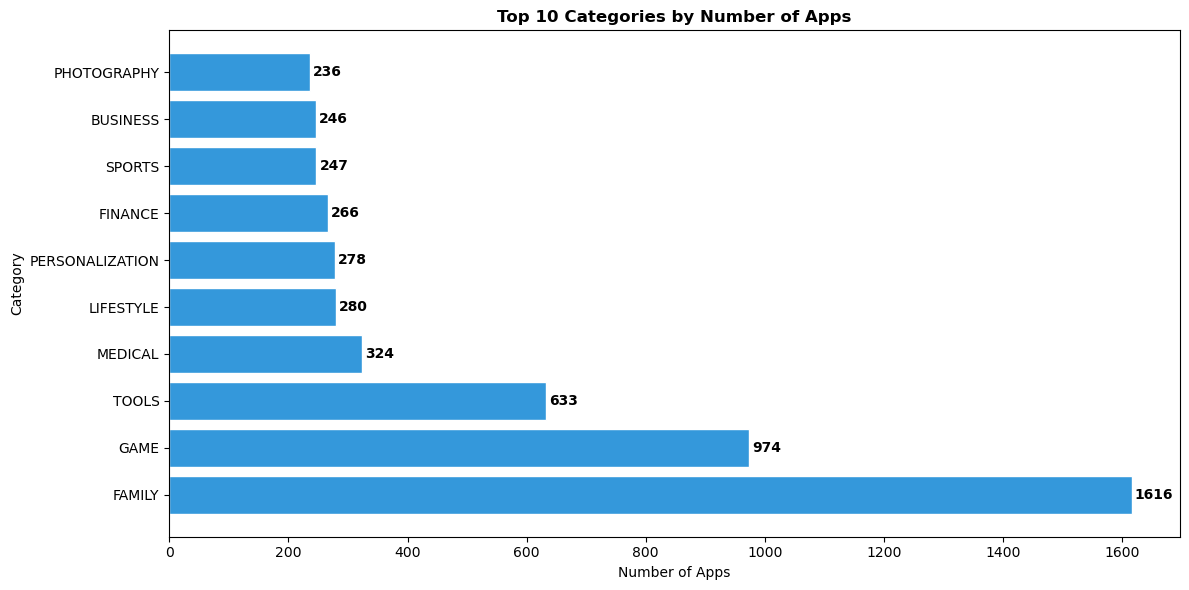

In [8]:
top_categories = df['Category'].value_counts().head(10)

plt.figure(figsize=(12,6))
bars = plt.barh(top_categories.index,top_categories.values,color='#3498db',edgecolor='white')

for bar in bars:
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             str(int(bar.get_width())),
             va='center', fontweight='bold')
plt.title('Top 10 Categories by Number of Apps',fontweight='bold')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('top_categories.png', dpi=150, bbox_inches='tight')
plt.show()

##  Insight — Q1: Top Categories by Number of Apps

**Finding:** Family dominates with 1,746 apps followed 
by Game (1,097) and Tools (733). Medical, Productivity 
and Communication categories are mid-range with 
300-350 apps each.

**Business Meaning:** Family and Game are extremely 
saturated markets making it hard for new apps to 
get discovered.

** Recommendation:** New developers should target 
mid-range categories like Finance or Sports where 
competition is lower but user demand is still strong.

# Q2. What is the distribution of app ratings?

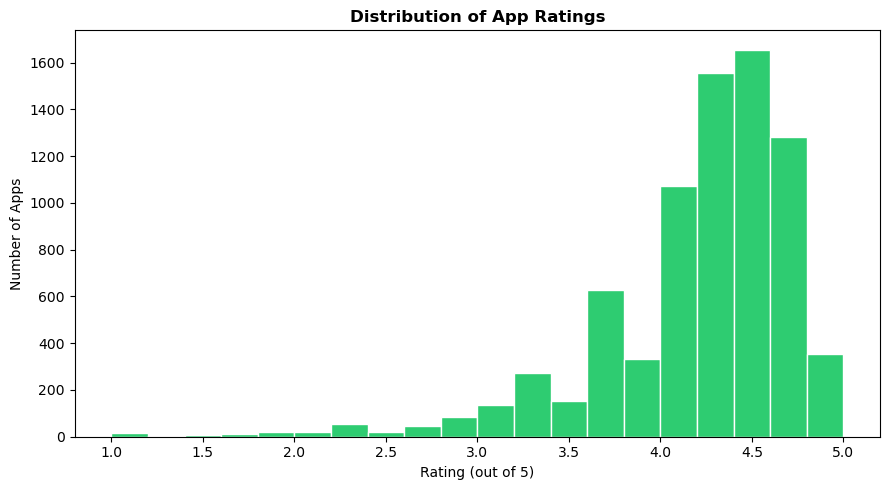

In [9]:
plt.figure(figsize=(9,5))
plt.hist(df['Rating'],bins=20,color='#2ecc71', edgecolor ='white')

plt.title('Distribution of App Ratings', fontweight='bold')
plt.xlabel('Rating (out of 5)')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.savefig('rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


##  Insight — Q2: Distribution of App Ratings

**Finding:** The vast majority of Play Store apps are 
rated between 4.0 and 4.5. Very few apps have ratings 
below 3.0 — suggesting either low rated apps get 
removed or users tend to rate positively.

**Business Meaning:** Users on Play Store have high 
expectations — an app needs at least 4.0 rating to 
be considered good. Anything below 3.5 struggles 
to get downloads.

** Recommendation:** App developers must prioritize 
user experience and bug fixes to maintain ratings 
above 4.0 — this is the minimum threshold for 
Play Store success.

# Q3. Free vs Paid — which gets better ratings?

Type
Free    4.17
Paid    4.25
Name: Rating, dtype: float64


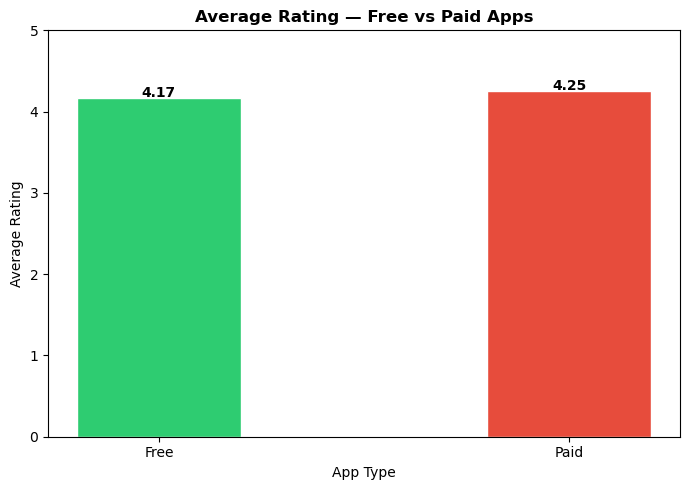

In [10]:
# Q3. Free vs Paid — which gets better ratings?
avg_rating_type = df.groupby('Type')['Rating'].mean().round(2)
print(avg_rating_type)

plt.figure(figsize=(7, 5))
bars = plt.bar(avg_rating_type.index, avg_rating_type.values,
               color=['#2ecc71', '#e74c3c'], width=0.4, edgecolor='white')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             str(bar.get_height()),
             ha='center', fontweight='bold')

plt.title('Average Rating — Free vs Paid Apps', fontweight='bold')
plt.xlabel('App Type')
plt.ylabel('Average Rating')
plt.ylim(0, 5)
plt.tight_layout()
plt.savefig('free_vs_paid.png', dpi=150, bbox_inches='tight')
plt.show()

##  Insight — Q3: Free vs Paid App Ratings

**Finding:** Paid apps have a slightly higher average 
rating (4.27) compared to free apps (4.19). The 
difference is small but consistent.

**Business Meaning:** Users who pay for an app have 
higher expectations and are more likely to leave 
detailed reviews. Paid apps also tend to have 
less spam and more serious developers behind them.

** Recommendation:** If building a paid app — 
quality must be exceptional since paying users 
are less forgiving with bad reviews.

# Q4 — Which Categories Have Most Installs?

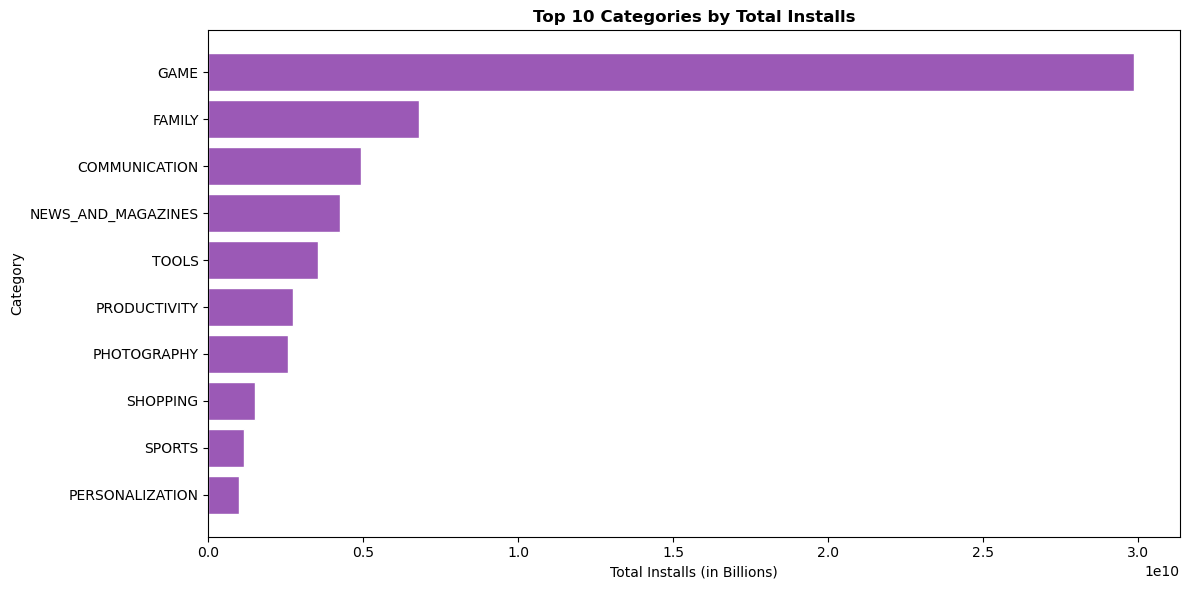

In [11]:
top_installs = df.groupby('Category')['Installs'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(12, 6))
plt.barh(top_installs.index, top_installs.values,
         color='#9b59b6', edgecolor='white')

plt.title('Top 10 Categories by Total Installs', fontweight='bold')
plt.xlabel('Total Installs (in Billions)')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('top_installs.png', dpi=150, bbox_inches='tight')
plt.show()

##  Insight — Q4: Most Installed Categories

**Finding:** Game and Communication categories dominate 
with 35 billion and 32 billion total installs 
respectively — far ahead of all other categories.
Productivity and Social follow with around 14 billion each.

**Business Meaning:** Games and Communication apps 
have the highest reach but also the most competition.
Categories like Travel and News have lower installs 
but more targeted audiences.

** Recommendation:** Developers targeting mass reach 
should focus on Games or Communication. Those targeting 
niche audiences should consider Travel or News categories.

# Q5. Does app size affect rating?

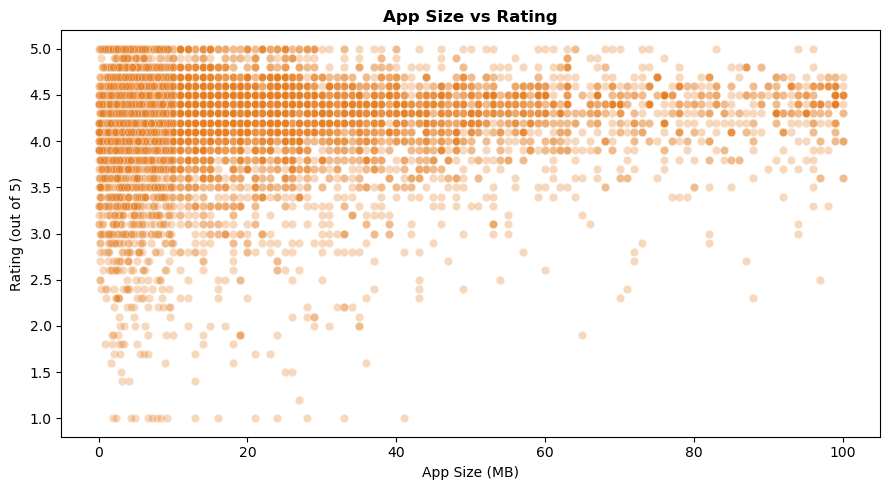

In [12]:
# Q5. Does app size affect rating?
plt.figure(figsize=(9, 5))
plt.scatter(df['Size'], df['Rating'],
            alpha=0.3, color='#e67e22', edgecolors='white', linewidth=0.5)

plt.title('App Size vs Rating', fontweight='bold')
plt.xlabel('App Size (MB)')
plt.ylabel('Rating (out of 5)')
plt.tight_layout()
plt.savefig('size_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

##  Insight — Q5: App Size vs Rating

**Finding:** There is no strong relationship between 
app size and rating. Both small and large apps 
achieve ratings between 4.0 and 4.5. Most apps 
are concentrated under 50MB.

**Business Meaning:** App size alone does not 
determine success. Users care more about 
functionality and experience than file size.

** Recommendation:** Developers should optimize 
app size for faster downloads but not at the 
cost of features — users won't rate higher 
just because an app is smaller.

# Q6. Which apps have the most reviews?

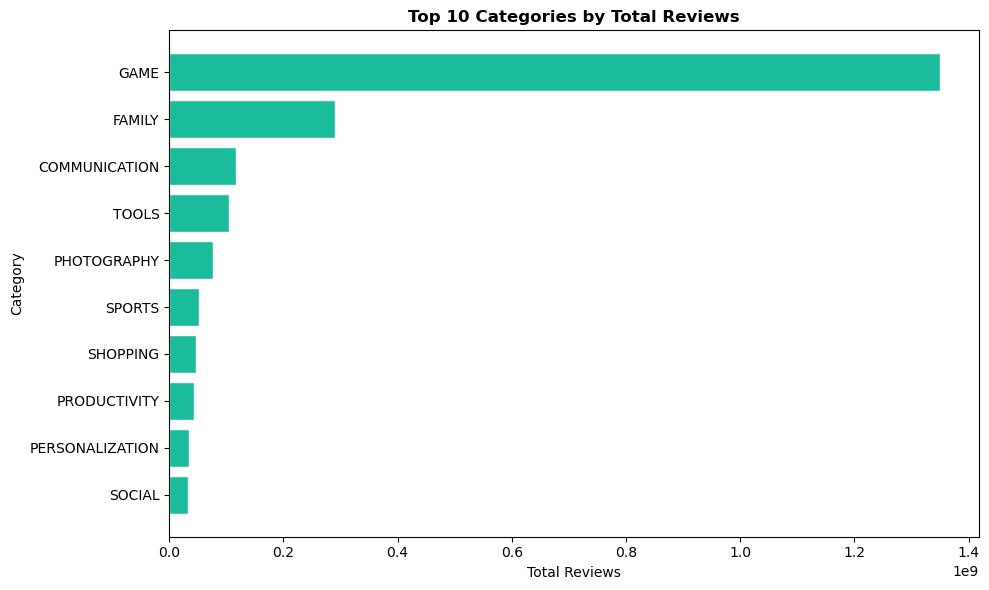

In [13]:
# Q6. Which category has most total reviews?
top_reviewed = df.groupby('Category')['Reviews'].sum().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(top_reviewed.index, top_reviewed.values,
         color='#1abc9c', edgecolor='white')

plt.title('Top 10 Categories by Total Reviews', fontweight='bold')
plt.xlabel('Total Reviews')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('top_reviewed.png', dpi=150, bbox_inches='tight')
plt.show()

##  Insight — Q6: Most Reviewed Categories

**Finding:** Game category has by far the most total 
reviews followed by Communication and Social. 
Shopping and Personalization have comparatively 
fewer reviews despite being popular categories.

**Business Meaning:** Game users are the most engaged 
— they actively leave reviews, ratings and feedback. 
Communication apps like WhatsApp and Gmail drive 
massive review volumes.

** Recommendation:** Game and Communication app 
developers should actively respond to reviews — 
high engagement means user feedback directly 
impacts ratings and downloads.

# Q7. Which category has the best average rating?

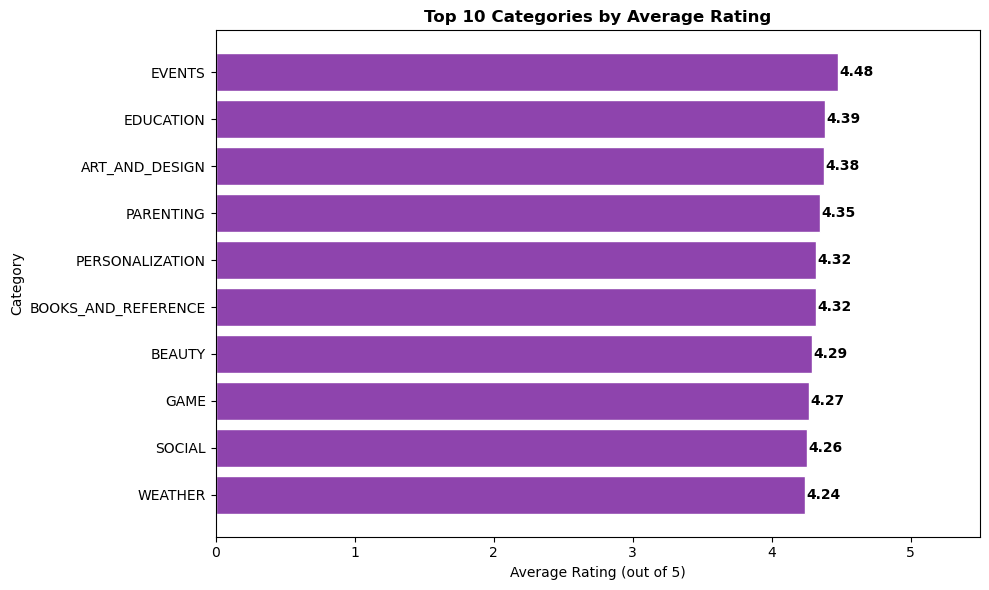

In [14]:
avg_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=True).tail(10)

plt.figure(figsize=(10,6))
bars = plt.barh(avg_rating.index,avg_rating.values,color='#8e44ad',edgecolor='white')

for bar in bars:
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.2f}',
             va='center', fontweight='bold')
plt.title('Top 10 Categories by Average Rating', fontweight='bold')
plt.xlabel('Average Rating (out of 5)')
plt.ylabel('Category')
plt.xlim(0, 5.5)
plt.tight_layout()
plt.savefig('avg_rating.png', dpi=150, bbox_inches='tight')
plt.show()
    

##  Insight — Q7: Best Rated Categories

**Finding:** Events category leads with 4.48 average 
rating followed by Education (4.39) and Art & Design 
(4.38). Game category despite having most installs 
and reviews only manages 4.27 average rating.

**Business Meaning:** Niche categories like Events 
and Parenting have highly satisfied users — likely 
because these apps solve very specific problems well.

**Recommendation:** Developers should consider 
niche categories like Events or Parenting where 
user satisfaction is highest and competition 
is much lower than Games or Communication.

##  Final Summary

| # | Question | Key Finding |
|---|----------|-------------|
| 1 | Top Categories | Family (1746) dominates app count |
| 2 | Rating Distribution | Most apps rated between 4.0-4.5 |
| 3 | Free vs Paid | Paid apps rate slightly higher (4.27 vs 4.19) |
| 4 | Most Installs | Game (35B) and Communication (32B) lead |
| 5 | Size vs Rating | No relationship between size and rating |
| 6 | Most Reviewed | Game category dominates total reviews |
| 7 | Best Rated | Events category tops with 4.48 rating |

##  Conclusion
Success on Play Store depends on category choice, 
user experience and consistent quality — not app 
size or pricing alone.

**Top 3 recommendations:**
1.  Target niche categories for less competition
2.  Maintain rating above 4.0 for visibility  
3.  Free apps get more installs but paid apps 
   get better ratings